# VALUE INVESTING ENGINE
By Julieta Mirensky

## MOTIVATION

Fundamentals represent business quality.
Market prices represent investor sentiment, emotions and market expectations.

This project focus mainly in the first one, using a Value Investing approach.

## OBJECTIVES

Build a simplified value investing tool that:

- Extracts financial fundamentals from S&P 500 companies
- Builds key value investing metrics
- Scores companies using 4 intuitive dimensions
- Ranks companies annually
- Analyse fundamentals as well as market behavior (“Mr. Market”)
- Produces datasets for Tableau dashboards

## MODULE 0 - LIBRARIES

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import random

import openpyxl

print ('LIBRARIES READY!')

LIBRARIES READY!


## MODULE 1 — UNIVERSE SELECTION

### STEP 1 — Get S&P500 Companies

In [ ]:

sp500_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"   # S&P500 members

headers = {  "User-Agent": "Mozilla/5.0"}

sp500_table = pd.read_html(requests.get(sp500_url, headers=headers).text)[0]  # Read HTML tables

sp500_df = sp500_table[['Symbol', 'Security']]

sp500_df.columns = ['ticker', 'company']  # Rename

sp500_df['ticker'] = sp500_df['ticker'].str.replace('.', '-', regex=False)  # Clean ticker formatting

print(f"S&P500 companies loaded: {len(sp500_df)}")

S&P500 companies loaded: 503


### STEP 2 — Selected universe (dependent on the analyst/user)

In [ ]:
# ticker list of 30 large-cap US hand-picked companies + 2 Fakes

tickers = [
    # Tech giants
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "ADBE", "CRM", "ORCL", "AMD",

    # Finance
    "JPM", "V", "MA", "BAC", "GS",

    # Consumer
    "PG", "KO", "PEP", "COST", "MCD",

    # Healthcare / Retail
    "JNJ", "UNH", "HD", "WMT", "DIS",

    # Energy / others
    "XOM", "CVX", "IBM", "NFLX", "INTC",

    # FAKE - # Non-S&P500 — to test the exclution by validation
     "MELI", "YPF"
]

tickers = [ticker.upper() for ticker in tickers]  # Uppercase formatting


### STEP 3 — Validate Tickers

In [ ]:

validation_results = []

for ticker in tickers:

    try:

        stock = yf.Ticker(ticker)

        info = stock.info

        valid_ticker = (
            info is not None and
            info.get("marketCap") is not None and
            info.get("currentPrice") is not None
        )

    except:

        valid_ticker = False


    in_sp500 = ticker in sp500_df['ticker'].values      # Check S&P500 membership


    validation_results.append({

        'ticker': ticker,
        'valid_ticker': valid_ticker,
        'in_sp500': in_sp500
    })

validation_df = pd.DataFrame(validation_results)

valid_mask = (
    (validation_df['valid_ticker'] == True) &
    (validation_df['in_sp500'] == True)
)

valid_tickers = (
    validation_df[valid_mask]['ticker']
    .tolist()
)

excluded_tickers = validation_df[~valid_mask]

print(f"\nVALID TICKERS: {len(valid_tickers)}")
print(valid_tickers)

print("\nEXCLUDED TICKERS")
print(excluded_tickers)
print(f"excluded tickers: {len(excluded_tickers)}")



VALID TICKERS: 30
['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'ADBE', 'CRM', 'ORCL', 'AMD', 'JPM', 'V', 'MA', 'BAC', 'GS', 'PG', 'KO', 'PEP', 'COST', 'MCD', 'JNJ', 'UNH', 'HD', 'WMT', 'DIS', 'XOM', 'CVX', 'IBM', 'NFLX', 'INTC']

EXCLUDED TICKERS
   ticker  valid_ticker  in_sp500
30   MELI          True     False
31    YPF          True     False
excluded tickers: 2


Those tickers that are not part of the benchmark index will be excluded from the analysis

## MODULE 2 — FINANCIAL DATA EXTRACTION

In [ ]:
financial_data = []

important_metrics = [
    # Income statement
    'Total Revenue',
    'Gross Profit',
    'Operating Income',
    'EBITDA',
    'Net Income',

    # Cash flow
    'Free Cash Flow',

    # Balance sheet
    'Total Assets',
    'Current Assets',
    'Current Liabilities',
    'Total Debt',
    'Total Liabilities Net Minority Interest',
    'Stockholders Equity',
    'Cash And Cash Equivalents'
]

for ticker in valid_tickers:
    print(f"Processing {ticker}...")

    try:
        stock = yf.Ticker(ticker)

        statements = {
            'income_statement': stock.financials,
            'balance_sheet': stock.balance_sheet,
            'cashflow': stock.cashflow
        }

        for statement_name, df in statements.items():

            if df.empty:
                continue

            df = df.T.reset_index()

            df = df.rename(columns={'index': 'date'})

            df['year'] = pd.to_datetime(df['date']).dt.year

            # Keep closed years only 2002, 2023, 2024, 2025 --> not 2021, not 2026
            df = df[(df['year'] < 2026) & (df['year'] > 2021)]

            df['ticker'] = ticker

            df_long = df.melt(
                id_vars=['ticker', 'date', 'year'],
                var_name='metric',
                value_name='value'
            )

            financial_data.append(df_long)

    except Exception as e:
        print(f"ERROR: {ticker} | {e}")

financial_df = pd.concat(financial_data, ignore_index=True)

financial_df['value'] = pd.to_numeric(
    financial_df['value'],
    errors='coerce'
)

print("Finished")


Processing AAPL...
Processing MSFT...
Processing GOOGL...
Processing AMZN...
Processing META...
Processing NVDA...
Processing ADBE...
Processing CRM...
Processing ORCL...
Processing AMD...
Processing JPM...
Processing V...
Processing MA...
Processing BAC...
Processing GS...
Processing PG...
Processing KO...
Processing PEP...
Processing COST...
Processing MCD...
Processing JNJ...
Processing UNH...
Processing HD...
Processing WMT...
Processing DIS...
Processing XOM...
Processing CVX...
Processing IBM...
Processing NFLX...
Processing INTC...
Finished


## MODULE 3 — Data Preparation



### STEP 1 - CLEANING

CORE METRICS ONLY

Only the metrics that are important in the context of Value Investing are selected.

In [ ]:
financial_core_df = financial_df[
    financial_df['metric'].isin(
        important_metrics
        ) ].copy()

print(financial_core_df.shape)

(1496, 5)


In [ ]:

financial_core_df.head()

,ticker,date,year,metric,value
24,AAPL,2025-09-30,2025,EBITDA,1.447480e+11
25,AAPL,2024-09-30,2024,EBITDA,1.346610e+11
26,AAPL,2023-09-30,2023,EBITDA,1.258200e+11
27,AAPL,2022-09-30,2022,EBITDA,1.305410e+11
84,AAPL,2025-09-30,2025,Net Income,1.120100e+11


In [ ]:
# Check by year
financial_core_df['year'].value_counts().sort_index()

,count
year,
2022,374
2023,374
2024,374
2025,374


In [ ]:
 # WIDE FORMAT --> pivote

df = financial_core_df.pivot_table(

    index=['ticker', 'year'],
    columns='metric',
    values='value'

).reset_index()

df = df.sort_values(['ticker', 'year'])


In [ ]:

print(f'shape: {df.shape}')
print()

print(f'First rows:\n {df.head()}')


shape: (116, 15)

First rows:
 metric ticker  year  Cash And Cash Equivalents  Current Assets  \
0        AAPL  2022               2.364600e+10    1.354050e+11   
1        AAPL  2023               2.996500e+10    1.435660e+11   
2        AAPL  2024               2.994300e+10    1.529870e+11   
3        AAPL  2025               3.593400e+10    1.479570e+11   
4        ADBE  2022               4.236000e+09    8.996000e+09   

metric  Current Liabilities        EBITDA  Free Cash Flow  Gross Profit  \
0              1.539820e+11  1.305410e+11    1.114430e+11  1.707820e+11   
1              1.453080e+11  1.258200e+11    9.958400e+10  1.691480e+11   
2              1.763920e+11  1.346610e+11    1.088070e+11  1.806830e+11   
3              1.656310e+11  1.447480e+11    9.876700e+10  1.952010e+11   
4              8.128000e+09  6.976000e+09    7.396000e+09  1.544100e+10   

metric    Net Income  Operating Income  Stockholders Equity  Total Assets  \
0       9.980300e+10      1.194370e+11      

In [ ]:
#Missing analysis

df_missing = (
    financial_core_df
    .groupby(['ticker', 'year'])
    .size()
    .unstack(fill_value=0)
)

df_missing



year,2022,2023,2024,2025
ticker,,,,
AAPL,13,13,13,13
ADBE,13,13,13,13
AMD,13,13,13,13
AMZN,13,13,13,13
BAC,8,8,8,8
COST,13,13,13,13
CRM,13,13,13,13
CVX,13,13,13,13
DIS,13,13,13,13


Yahoo Finance does not provide complete data for all companies in the selected period; there are missing values for some Financial institutions (BAC, GS, JPM). As a consequence:

- the mentioned 3 firms were excluded due to inconsistent reporting over the time period.


In [ ]:
excluded_financials = ['BAC', 'GS', 'JPM']

df = df[~df['ticker'].isin(excluded_financials)]

df = df.sort_values(
    ['ticker', 'year']
)

print(df.shape) # from 116 rows to 104


(104, 15)


### STEP 2 - "Mr Market" DATA

**Very important limitation!!**

Historical market capitalization is estimated using year-end closing prices and latest available shares outstanding data.

In [ ]:

market_data = []

valid_tickers = (
    df['ticker']
    .unique()
    .tolist()
)

for ticker in valid_tickers:

    try:

        print(f"Market data: {ticker}")

        stock = yf.Ticker(ticker)

        price_history = stock.history(

            start='2022-01-01',
            end='2026-01-01'

        ).reset_index()

        price_history['year'] = (
            price_history['Date'].dt.year
        )

        yearly_price = (

            price_history
            .sort_values('Date')
            .groupby('year')
            .tail(1)

        )

        shares_outstanding = stock.info.get(
            'sharesOutstanding',
            np.nan
        )

        for _, row in yearly_price.iterrows():

            market_data.append({

                'ticker': ticker,
                'year': row['year'],
                'close_price': row['Close'],

                # Estimated market cap proxy
                'estimated_market_cap':
                    row['Close'] * shares_outstanding
            })

    except Exception as e:

        print(f"ERROR: {ticker} | {e}")


market_df = pd.DataFrame(market_data)

print("MARKET DATA READY")
print()
print(market_df.head())





Market data: AAPL
Market data: ADBE
Market data: AMD
Market data: AMZN
Market data: COST
Market data: CRM
Market data: CVX
Market data: DIS
Market data: GOOGL
Market data: HD
Market data: IBM
Market data: INTC
Market data: JNJ
Market data: KO
Market data: MA
Market data: MCD
Market data: META
Market data: MSFT
Market data: NFLX
Market data: NVDA
Market data: ORCL
Market data: PEP
Market data: PG
Market data: UNH
Market data: V
Market data: WMT
Market data: XOM
MARKET DATA READY

  ticker  year  close_price  estimated_market_cap
0   AAPL  2022   127.761627          1.876481e+12
1   AAPL  2023   190.375092          2.796107e+12
2   AAPL  2024   248.830200          3.654658e+12
3   AAPL  2025   271.355835          3.985500e+12
4   ADBE  2022   336.529999          1.360254e+11


### STEP 3 - MERGE DATASETS

In [ ]:
final_df = df.merge(
    market_df,
    on=['ticker', 'year'],
    how='left'
)

In [ ]:
# Data Quality Check

print(f'shape: {final_df.shape}')
print()

print(f'First rows:\n {final_df.head()}')
print()

print('data types & missings')
final_df.info()
print()

print(f'Duplicates?  {final_df.duplicated().sum()}')



shape: (104, 17)

First rows:
   ticker  year  Cash And Cash Equivalents  Current Assets  \
0   AAPL  2022               2.364600e+10    1.354050e+11   
1   AAPL  2023               2.996500e+10    1.435660e+11   
2   AAPL  2024               2.994300e+10    1.529870e+11   
3   AAPL  2025               3.593400e+10    1.479570e+11   
4   ADBE  2022               4.236000e+09    8.996000e+09   

   Current Liabilities        EBITDA  Free Cash Flow  Gross Profit  \
0         1.539820e+11  1.305410e+11    1.114430e+11  1.707820e+11   
1         1.453080e+11  1.258200e+11    9.958400e+10  1.691480e+11   
2         1.763920e+11  1.346610e+11    1.088070e+11  1.806830e+11   
3         1.656310e+11  1.447480e+11    9.876700e+10  1.952010e+11   
4         8.128000e+09  6.976000e+09    7.396000e+09  1.544100e+10   

     Net Income  Operating Income  Stockholders Equity  Total Assets  \
0  9.980300e+10      1.194370e+11         5.067200e+10  3.527550e+11   
1  9.699500e+10      1.143010e+11    

## MODULE 4 - KPI ENGINE

In [ ]:
# FEATURE ENGINEERING!

# SAFE DIVISION
def safe_div(a, b):
    return np.where(
        b != 0,
        a / b,
        np.nan )


# QUALITY (good business?)

final_df['roe'] = safe_div(final_df['Net Income'], final_df['Stockholders Equity'] )

# ROIC
tax_rate = 0.21
final_df['nopat'] = ( final_df['Operating Income'] * (1 - tax_rate) )
final_df['invested_capital'] = ( final_df['Total Assets'] - final_df['Current Liabilities'])

final_df['roic'] = safe_div( final_df['nopat'], final_df['invested_capital'] )

final_df['operating_margin'] = safe_div(  final_df['Operating Income'], final_df['Total Revenue'] )


# FINANCIAL HEALTH (Is it safe?)

final_df['current_ratio'] = safe_div( final_df['Current Assets'], final_df['Current Liabilities'] )

final_df['debt_to_equity'] = safe_div( final_df['Total Debt'], final_df['Stockholders Equity'] )


# VALUATION (PRICE cheap or expensive?)

# free cash flow in comparison to every dollar I pay for the company
final_df['fcf_yield'] = safe_div( final_df['Free Cash Flow'], final_df['estimated_market_cap'] )


final_df['enterprise_value'] = ( final_df['estimated_market_cap'] +  final_df['Total Debt'] -  final_df['Cash And Cash Equivalents'] )

final_df['ev_ebitda'] = safe_div( final_df['enterprise_value'], final_df['EBITDA'] )

shares = final_df['estimated_market_cap'] / final_df['close_price']

final_df['eps'] = safe_div( final_df['Net Income'], shares)

final_df['pe_ratio'] = safe_div( final_df['close_price'], final_df['eps'] )


# Cash Flow & Growth

final_df['fcf_margin'] = safe_div( final_df['Free Cash Flow'], final_df['Total Revenue'] )

final_df['revenue_growth'] = (
    final_df
    .groupby('ticker')['Total Revenue']
    .pct_change(fill_method=None)
)

final_df['eps_growth'] = (
    final_df
    .groupby('ticker')['eps']
    .pct_change(fill_method=None)
)


### Data Quality Filter

In [ ]:
final_df = final_df.copy()

print(f"Records before cleaning: {len(final_df)}")

Records before cleaning: 104


In [ ]:
score_df = final_df.copy()

No financial scoring is performed on incomplete observations. Companies with excessive missing fundamental indicators are excluded prior to normalization and ranking to ensure comparability and avoid bias.

In [ ]:
scoring_metrics = [
     'roe', 'roic', 'operating_margin',           # QUALITY
     'current_ratio', 'debt_to_equity',           # FINANCIAL HEALTH
     'fcf_yield', 'ev_ebitda', 'pe_ratio',        # VALUATION
     'fcf_margin', 'revenue_growth', 'eps_growth' # Cash Flow & Growth
]

# DATA QUALITY FILTER
score_df["missing_ratio"] = (
    score_df[scoring_metrics]
    .isna()
    .mean(axis=1)
)

# if more than 50% of metrics are missing → gone!
score_df = score_df[score_df["missing_ratio"] <= 0.5].copy()

print(f"Records after cleaning: {len(score_df)}")

Records after cleaning: 104


## MODULE 5 — INVESTMENT SCORING

In [ ]:
# ==========================================
# NORMALIZATION
# ==========================================

higher_better = [
    'roe',
    'roic',
    'operating_margin',

    'fcf_margin',

    'current_ratio',

    'revenue_growth',
    'eps_growth',

    'fcf_yield'
]

lower_better = [
    'debt_to_equity',
    'pe_ratio',
    'ev_ebitda'
]


''''Percentile ranking by year — eliminates scale differences
and enables cross-sectional comparison between companies.'''

for metric in higher_better:
    score_df[f'{metric}_score'] = (score_df.groupby('year')[metric].rank(pct=True))

for metric in lower_better:
    score_df[f'{metric}_score'] = (
        1 - score_df.groupby('year')[metric].rank(pct=True))



In [ ]:
# ==========================================
# SUB-SCORES - 4 Dimensions or factors
# ==========================================

score_df['quality_score'] = (
    score_df['roe_score'] * 0.30 +
    score_df['roic_score'] * 0.40 +
    score_df['operating_margin_score'] * 0.30
)

score_df['financial_health_score'] = (
    score_df['current_ratio_score'] * 0.40 +
    score_df['debt_to_equity_score'] * 0.60
)

score_df['valuation_score'] = (
    score_df['fcf_yield_score'] * 0.50 +
    score_df['ev_ebitda_score'] * 0.30 +
    score_df['pe_ratio_score'] * 0.20
)

score_df['cash_generation_growth_score'] = (
    score_df['fcf_margin_score'] * 0.60 +
    score_df['revenue_growth_score'] * 0.20 +
    score_df['eps_growth_score'] * 0.20
)



In [ ]:
# ==========================================
# FINAL SCORE
# ==========================================

score_df['investment_score'] = (
    score_df['quality_score'] * 0.30 +
    score_df['financial_health_score'] * 0.20 +
    score_df['valuation_score'] * 0.25 +
    score_df['cash_generation_growth_score'] * 0.25
)


In [ ]:
# ==========================================
# RANKING
# ==========================================

score_df['investment_rank'] = (
    score_df.groupby('year')['investment_score']
    .rank( ascending=False,  method='dense' )
)

In [ ]:
# ==========================================
# INVESTMENT SIGNALS
# ==========================================

conditions = [
    score_df['investment_score'] >= 0.65,
    (score_df['investment_score'] >= 0.55) & (score_df['investment_score'] < 0.65) ,
    score_df['investment_score'] < 0.55
]

choices = [ 'BUY', 'HOLD', 'AVOID'
]

score_df['investment_signal'] = np.select(
    conditions,
    choices,
    default='NO SIGNAL'
)


### RANKING

In [ ]:

final_ranking = score_df[[
    'ticker',
    'year',

    'quality_score',
    'financial_health_score',
    'valuation_score',
    'cash_generation_growth_score',

    'investment_score',
    'investment_rank',
    'investment_signal'
]]

final_ranking = final_ranking.sort_values(
    ['year', 'investment_rank']
)



In [ ]:
cols = ['quality_score', 'financial_health_score', 'valuation_score', 'cash_generation_growth_score', 'investment_score']

final_ranking[cols] = final_ranking[cols].round(3)

display(final_ranking.tail(27))


,ticker,year,quality_score,financial_health_score,valuation_score,cash_generation_growth_score,investment_score,investment_rank,investment_signal
7,ADBE,2025,0.844,0.415,0.867,0.800,0.753,1.0,BUY
34,GOOGL,2025,0.670,0.852,0.785,0.652,0.731,2.0,BUY
76,NVDA,2025,0.956,0.933,0.081,0.941,0.729,3.0,BUY
96,V,2025,0.874,0.437,0.426,0.793,0.654,4.0,BUY
65,META,2025,0.630,0.726,0.563,0.652,0.638,5.0,HOLD
57,MA,2025,0.937,0.237,0.363,0.852,0.632,6.0,HOLD
73,NFLX,2025,0.711,0.585,0.456,0.704,0.620,7.0,HOLD
69,MSFT,2025,0.696,0.778,0.278,0.711,0.612,8.0,HOLD
22,CRM,2025,0.304,0.667,0.641,0.793,0.583,9.0,HOLD
49,JNJ,2025,0.519,0.407,0.704,0.637,0.572,10.0,HOLD


**Key finding:**

In 2025, 4 companies received a BUY signal:
- ADBE
- GOOGL
- NVDA
- V

This represents almost 15% of the analyzed universe.

In [ ]:
summary_df = score_df[

    score_df['year'].isin(
        [2022, 2023, 2024, 2025]
    )

].copy()

score_history = summary_df.pivot_table(

    index='ticker',
    columns='year',
    values='investment_score'

)

score_history['avg_score'] = (
    score_history.mean(axis=1)
)

score_history['score_std'] = (
    score_history[[2023, 2024, 2025]]
    .std(axis=1)
)

score_history = score_history.sort_values(

    'avg_score',
    ascending=False

)

score_history = score_history.round(3)

print(score_history)

year     2023   2024   2025  avg_score  score_std
ticker                                           
GOOGL   0.792  0.792  0.731      0.772      0.035
META    0.799  0.764  0.638      0.734      0.085
NVDA      NaN  0.691  0.729      0.710      0.027
V       0.757  0.701  0.654      0.704      0.051
ADBE    0.637  0.669  0.753      0.686      0.060
MA      0.662  0.612  0.632      0.635      0.025
MSFT    0.613  0.644  0.612      0.623      0.018
MCD     0.677  0.593  0.562      0.611      0.059
JNJ     0.670  0.548  0.572      0.597      0.065
NFLX    0.520  0.546  0.620      0.562      0.052
AAPL    0.567  0.540  0.541      0.549      0.015
HD        NaN  0.564  0.525      0.545      0.028
CRM       NaN  0.499  0.583      0.541      0.059
XOM     0.577  0.554  0.475      0.535      0.053
KO      0.561  0.437  0.463      0.487      0.065
PG      0.486  0.491  0.481      0.486      0.005
CVX     0.530  0.467  0.449      0.482      0.042
IBM     0.511  0.425  0.456      0.464      0.044


## MODULE 6 — MARKET ANALYSIS

In [ ]:
df_analytics = score_df.copy()

### STEP 1 — DAILY PRICES + MA200

In [ ]:
MARKET_TICKER = "^GSPC"

print("Downloading daily prices...")

# S&P500 benchmark
sp500_hist = (
    yf.Ticker(MARKET_TICKER)
    .history(
        start="2022-01-01",
        end="2026-01-01"
    )[["Close"]]
)

sp500_hist.index = (
    pd.to_datetime(sp500_hist.index)
    .tz_localize(None)
)

sp500_hist = sp500_hist.rename(
    columns={"Close": "sp500_close"}
)

daily_prices = []

for ticker in valid_tickers:

    try:

        print(f"Processing {ticker}...")

        hist = (
            yf.Ticker(ticker)
            .history(
                start="2022-01-01",
                end="2026-01-01"
            )[["Close"]]
        )

        hist.index = (
            pd.to_datetime(hist.index)
            .tz_localize(None)
        )

        hist = hist.rename(
            columns={"Close": "close"}
        )

        # First 200 days will contain NaN
        hist["ma200"] = (
            hist["close"]
            .rolling(200)
            .mean()
        )

        # Stock cumulative return
        hist["stock_cumreturn"] = (
            hist["close"] /
            hist["close"].iloc[0]
        ) - 1

        # Merge benchmark
        hist = hist.join(
            sp500_hist,
            how="left"
        )

        # Benchmark cumulative return
        hist["sp500_cumreturn"] = (
            hist["sp500_close"] /
            hist["sp500_close"].iloc[0]
        ) - 1

        # Excess return
        hist["excess_return"] = (
            hist["stock_cumreturn"] -
            hist["sp500_cumreturn"]
        )

        # Trend signal
        hist["trend"] = np.where(
            hist["close"] > hist["ma200"],
            "Bullish",
            "Bearish"
        )

        hist["ticker"] = ticker

        hist = (
            hist
            .reset_index()
            .rename(
                columns={
                    "index": "date",
                    "Date": "date"
                }
            )
        )

        daily_prices.append(hist)

    except Exception as e:

        print(f"ERROR: {ticker} | {e}")


tableau_daily = pd.concat(
    daily_prices,
    ignore_index=True
)



tableau_daily = tableau_daily[[

    "ticker",
    "date",

    "close",
    "ma200",

    "stock_cumreturn",
    "sp500_cumreturn",
    "excess_return",

    "trend"

]]

print(tableau_daily.shape)



Processing AAPL...
Processing ADBE...
Processing AMD...
Processing AMZN...
Processing COST...
Processing CRM...
Processing CVX...
Processing DIS...
Processing GOOGL...
Processing HD...
Processing IBM...
Processing INTC...
Processing JNJ...
Processing KO...
Processing MA...
Processing MCD...
Processing META...
Processing MSFT...
Processing NFLX...
Processing NVDA...
Processing ORCL...
Processing PEP...
Processing PG...
Processing UNH...
Processing V...
Processing WMT...
Processing XOM...
(27081, 8)


### STEP 2 - DEMO CHARTS

Selected ticker: INTC


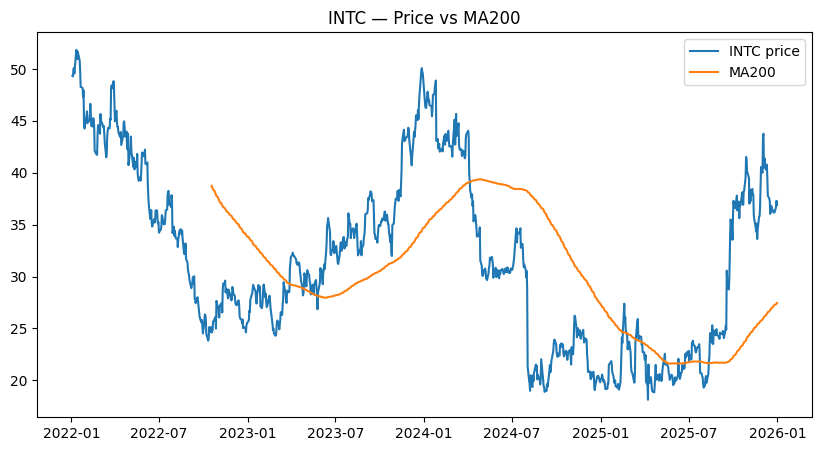

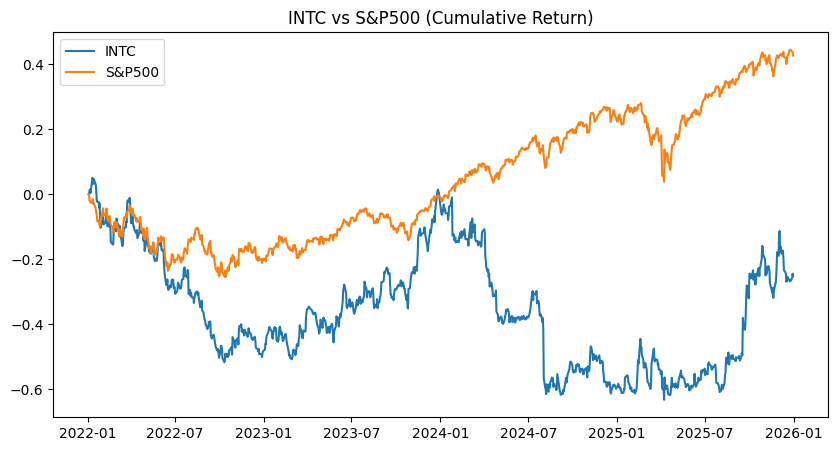


=== PERFORMANCE SUMMARY ===
Win rate vs S&P500: 2.1%
Underperformance rate: 97.9%

Total return INTC: -25.2%
S&P500 return: 42.7%


In [ ]:

# random ticker
ticker = random.choice(valid_tickers)
print("Selected ticker:", ticker)

# filter data
df_t = tableau_daily[tableau_daily["ticker"] == ticker].copy()

# Ensure format
df_t["date"] = pd.to_datetime(df_t["date"])


# chart 1: price vs moving average
plt.figure(figsize=(10,5))
plt.plot(df_t["date"], df_t["close"], label=f"{ticker} price")
plt.plot(df_t["date"], df_t["ma200"], label="MA200")
plt.title(f"{ticker} — Price vs MA200")
plt.legend()
plt.show()


# chart 2: stock vs S&P500
plt.figure(figsize=(10,5))
plt.plot(df_t["date"], df_t["stock_cumreturn"], label=f"{ticker}")
plt.plot(df_t["date"], df_t["sp500_cumreturn"], label="S&P500")
plt.title(f"{ticker} vs S&P500 (Cumulative Return)")
plt.legend()
plt.show()


#  win rate vs benchmark
monthly = df_t.set_index("date").resample("M").last()
monthly["outperform"] = monthly["stock_cumreturn"] > monthly["sp500_cumreturn"]

win_rate = monthly["outperform"].mean() * 100
loss_rate = 100 - win_rate

print("\n=== PERFORMANCE SUMMARY ===")
print(f"Win rate vs S&P500: {win_rate:.1f}%")
print(f"Underperformance rate: {loss_rate:.1f}%")

# final total return
total_return = df_t["stock_cumreturn"].iloc[-1] * 100
benchmark_return = df_t["sp500_cumreturn"].iloc[-1] * 100

print(f"\nTotal return {ticker}: {total_return:.1f}%")
print(f"S&P500 return: {benchmark_return:.1f}%")

## MODULE 7 - FOR TABLEAU EXPORT

In [ ]:
# METADATA

print("Downloading metadata...")

metadata = []

for ticker in valid_tickers:

    try:

        info = yf.Ticker(ticker).info

        metadata.append({

            "ticker": ticker,

            "company":
                info.get("longName", "N/A"),

            "sector":
                info.get("sector", "N/A"),

            "industry":
                info.get("industry", "N/A"),
        })

    except Exception as e:

        print(f"ERROR: {ticker} | {e}")


tableau_metadata = pd.DataFrame(metadata)

print(tableau_metadata.shape)



(27, 4)


In [ ]:
# MAIN DATASET

main_cols = [

    # IDs
    "ticker",
    "year",

    # Scores
    "quality_score",
    "financial_health_score",
    "valuation_score",
    'cash_generation_growth_score',

    "investment_score",
    "investment_rank",
    "investment_signal",

    # Core KPIs
    "roe",
    "roic",
    "operating_margin",

    "current_ratio",
    "debt_to_equity",

    "fcf_yield",
    "pe_ratio",
    "ev_ebitda",

    "fcf_margin",
    "revenue_growth",
    "eps_growth",

     "eps",

    # Market
    "close_price",
    "estimated_market_cap",

     # Raw financials
    "Total Revenue",
    "Gross Profit",
    "Operating Income",
    "EBITDA",
    "Net Income",
    "Free Cash Flow",

    "Total Assets",
    "Total Debt",
    "Stockholders Equity",

    "Cash And Cash Equivalents",
    "Current Assets",
    "Current Liabilities"

]

available_cols = [
    col for col in main_cols
    if col in df_analytics.columns
]

tableau_main = (
    df_analytics[available_cols]
    .copy()
)

# Merge metadata
tableau_main = tableau_main.merge(

    tableau_metadata[[
        "ticker",
        "company",
        "sector",
        "industry" ]],

    on="ticker",
    how="left"

)

tableau_main = tableau_main.sort_values(
    ["year", "investment_rank"]
)

print(tableau_main.shape)


(104, 38)


In [ ]:

def clean_numeric(df):

    return df.replace(
        [np.inf, -np.inf],
        np.nan
    )

final_df = clean_numeric(final_df)
tableau_main = clean_numeric(tableau_main)
tableau_daily = clean_numeric(tableau_daily)

In [ ]:
tableau_main.head()

,ticker,year,quality_score,financial_health_score,valuation_score,cash_generation_growth_score,investment_score,investment_rank,investment_signal,roe,...,Free Cash Flow,Total Assets,Total Debt,Stockholders Equity,Cash And Cash Equivalents,Current Assets,Current Liabilities,company,sector,industry
0,AAPL,2022,0.921739,0.069565,0.739130,NaN,NaN,NaN,NO SIGNAL,1.969589,...,1.114430e+11,3.527550e+11,1.324800e+11,5.067200e+10,2.364600e+10,1.354050e+11,1.539820e+11,Apple Inc.,Technology,Consumer Electronics
4,ADBE,2022,0.821739,0.565217,0.500000,NaN,NaN,NaN,NO SIGNAL,0.338481,...,7.396000e+09,2.716500e+10,4.633000e+09,1.405100e+10,4.236000e+09,8.996000e+09,8.128000e+09,Adobe Inc.,Technology,Software - Application
8,AMD,2022,0.139130,0.904348,0.278261,NaN,NaN,NaN,NO SIGNAL,0.024110,...,3.115000e+09,6.758000e+10,2.863000e+09,5.475000e+10,4.835000e+09,1.501900e+10,6.369000e+09,"Advanced Micro Devices, Inc.",Technology,Semiconductors
12,AMZN,2022,0.121739,0.234783,0.234783,NaN,NaN,NaN,NO SIGNAL,-0.018638,...,-1.689300e+10,4.626750e+11,1.401180e+11,1.460430e+11,5.388800e+10,1.467910e+11,1.553930e+11,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail
16,COST,2022,0.504348,0.469565,0.234783,NaN,NaN,NaN,NO SIGNAL,0.283112,...,3.501000e+09,6.416600e+10,9.039000e+09,2.064200e+10,1.020300e+10,3.269600e+10,3.199800e+10,Costco Wholesale Corporation,Consumer Defensive,Discount Stores


###  EXCEL EXPORT

In [ ]:
with pd.ExcelWriter("value_investing_for_tableau.xlsx", engine="openpyxl") as writer:

    tableau_main.to_excel(
        writer,
        sheet_name="tableau_main",
        index=False
    )

    tableau_daily.to_excel(
        writer,
        sheet_name="tableau_daily",
        index=False
    )

print("\nEXPORT COMPLETED → value_investing_for_tableau.xlsx")


EXPORT COMPLETED → value_investing_for_tableau.xlsx


## MODULE 8 - BACKTESTING

- Future returns are computed using available annual closing prices.
- 2025 is excluded since forward prices are not yet available.
- This backtesting framework should be considered illustrative rather than a fully validation for Investment Score and Investment Signal.

In [ ]:
# Build backtesting dataset using available data from tableau_main

df_backtest = tableau_main[[
    'ticker',
    'year',
    'investment_score',
    'investment_signal',
    'close_price',
    'company',
    'sector',
    'industry'
]].copy()

df_backtest = df_backtest.sort_values(['ticker', 'year'])  # Sort values to ensure correct time-series structure


In [ ]:
# =========================
# FUTURE RETURNS CALCULATION
# =========================

# Get next year's closing price per company
df_backtest['next_close'] = (
    df_backtest.groupby('ticker')['close_price']
      .shift(-1)
)

# Compute forward return (t → t+1)
df_backtest['future_return'] = (
    df_backtest['next_close'] / df_backtest['close_price'] - 1
).round(4)

In [ ]:
# FILTER BUY SIGNALS
buy_df = df_backtest[df_backtest['investment_signal'] == 'BUY'].copy()

In [ ]:
# Remove last available year (no future data available) (2026 not finished yet)
buy_df = buy_df[buy_df['future_return'].notna()]

In [ ]:
# =========================
# BACKTEST RESULTS
# =========================

# Average return of BUY signals
avg_buy_return = buy_df['future_return'].mean().round(4)

# Success rate (positive returns above threshold)
success_rate = (buy_df['future_return'] > 0.01).mean().round(4)  # min 10%

print ( f'Average BUY Return: {avg_buy_return} | BUY Success Rate {success_rate}')


# BUY Success Rate ~ 72.7% only computed on 11 BUY observations (not a statistical proof yet)


Average BUY Return: 0.2294 | BUY Success Rate 0.7273


In [ ]:
# BEST PERFORMING IDEAS
buy_df.sort_values('future_return', ascending=False)


,ticker,year,investment_score,investment_signal,close_price,company,sector,industry,next_close,future_return
63,META,2023,0.799034,BUY,351.203918,"Meta Platforms, Inc.",Communication Services,Internet Content & Information,583.170288,0.6605
33,GOOGL,2024,0.791852,BUY,188.316376,Alphabet Inc.,Communication Services,Internet Content & Information,312.593109,0.6599
75,NVDA,2024,0.690926,BUY,134.089737,NVIDIA Corporation,Technology,Semiconductors,186.272812,0.3892
32,GOOGL,2023,0.792110,BUY,138.462204,Alphabet Inc.,Communication Services,Internet Content & Information,188.316376,0.3601
55,MA,2023,0.661506,BUY,420.279938,Mastercard Incorporated,Financial Services,Credit Services,521.879761,0.2417
94,V,2023,0.756691,BUY,255.495300,Visa Inc.,Financial Services,Credit Services,312.517487,0.2232
64,META,2024,0.763889,BUY,583.170288,"Meta Platforms, Inc.",Communication Services,Internet Content & Information,659.525330,0.1309
95,V,2024,0.701111,BUY,312.517487,Visa Inc.,Financial Services,Credit Services,349.264221,0.1176
59,MCD,2023,0.676779,BUY,279.429382,McDonald's Corporation,Consumer Cyclical,Restaurants,279.811188,0.0014
47,JNJ,2023,0.670306,BUY,145.799438,Johnson & Johnson,Healthcare,Drug Manufacturers - General,138.784378,-0.0481


## MODULE 9- Requirements

In [ ]:
print("pandas==", pd.__version__)
print("numpy==", np.__version__)
print("yfinance==", yf.__version__)
print("requests==", requests.__version__)
print("matplotlib==", plt.matplotlib.__version__)
print("openpyxl==", openpyxl.__version__)


pandas== 2.2.2
numpy== 2.0.2
yfinance== 0.2.66
requests== 2.32.4
matplotlib== 3.10.0
openpyxl== 3.1.5
